# Duplicate of sampling.ipynb for doing repeated runs

## 0.1. Imports and load data

In [2]:
import ase.io
from pathlib import Path
import numpy as np
import importlib
import torch
import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [3]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 500  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 500 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))

base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Train base model



In [4]:
base_model_training_result = training.train_model(
    base_atoms_list,
    max_epochs=10
)

base_model = base_model_training_result.model
z_table = base_model_training_result.z_table
base_history = base_model_training_result.history
base_encoder = base_model_training_result.encoder

/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

{'stage': 'base_model', 'epoch': 1, 'train_loss': 107.93402940750121, 'valid_loss': 89.07300842285156, 'seconds': 27.12}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 25.219936113357544, 'valid_loss': 24.50059341430664, 'seconds': 26.04}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 21.637628936767577, 'valid_loss': 21.982149085998536, 'seconds': 24.22}

Training complete after 10 epochs
Final train loss: 21.637629
Final valid loss: 21.982149


In [ ]:
# save model
base_model_filename = "base_model_propene_500_geometries_for_pca_testing.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
torch.save(base_model, base_model_save_path)
print(f"Base model saved to {base_model_save_path}")

Base model saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/base_models/base_model_propene_500_geometries_for_pca_testing.pt


## 1. Choose descriptor

In [5]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[4]  # choose the descriptor type to use

# matrix of descriptors for each geometry
desc_matrix = []
for atom in transfer_atoms_list:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 8568)
desc_matrix unique shape: (500, 8568)
desc_matrix:
 [[ 0.00030844  0.00157082 -0.00142176 ...  0.01473969  0.00809319
   0.05301883]
 [ 0.0002354   0.00156904 -0.00140247 ...  0.02580532  0.00662088
   0.02677245]
 [ 0.00023981  0.00158105 -0.00148171 ...  0.02535578  0.00541872
   0.02930187]
 ...
 [ 0.00024234  0.00158632 -0.0015129  ...  0.02506242  0.00499292
   0.03040973]
 [ 0.00026874  0.00161578 -0.00166273 ...  0.02160602  0.00358162
   0.03885796]
 [ 0.00026622  0.00161447 -0.00165697 ...  0.02195626  0.00358079
   0.03813839]]


In [ ]:
# Optional dimensionality reduction using PCA

PCA_DIMENSIONS = 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=PCA_DIMENSIONS)
desc_matrix = pca.fit_transform(desc_matrix_scaled)

print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 3)
desc_matrix unique shape: (500, 3)
desc_matrix:
 [[ 25.66290073  -7.5435525    3.57461524]
 [-17.68889132  -1.97186744 -11.88806588]
 [ -9.68128667   8.30790249  11.93837659]
 ...
 [ -4.73528134  13.40840203  -1.75137886]
 [ -0.93051678  -9.05129291  -4.19616038]
 [ -3.10642808 -11.28432425  -3.91061191]]


## 2. Choose selector

In [6]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "birch", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[5]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES)

# sampled atoms
sampled_atoms = [transfer_atoms_list[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

n clusters: 1
n clusters with samples: 1
labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

## 3. Repeated runs of training transfer model

In [12]:
lowest_losses = []

In [13]:
for _ in range(50):
    SELECTOR = "random_sampling"  # choose the selector type to use

    # number of samples to select from the transfer dataset
    N_SAMPLES = 100

    # select samples based on the descriptor matrix
    sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES)

    # sampled atoms
    sampled_atoms = [transfer_atoms_list[i] for i in sampled_idx]

    print("sampled indices:\n", sampled_idx)
    print("number sampled:", len(sampled_idx))
    
    transfer_model_training_result = training.train_model(
        sampled_atoms,
        model=base_model,
        z_table=z_table,
        max_epochs=10,
    )

    transfer_history = transfer_model_training_result.history
    transfer_valid_losses = [row["valid_loss"] for row in transfer_history]
    
    print(np.min(transfer_valid_losses))
    lowest_losses.append(np.min(transfer_valid_losses))
    print(lowest_losses)

sampled indices:
 [229 337 327 416 306 131   5 431 434 134 276 264  34 274 489  11 378 467
 425 241  93 310 189 277 138 332 313  59 212 171 375  85 266  36 272 287
 185 338  33 343 363   9 204 472  48 280  15 184  24  82 289 182  13 114
 475 440 308 368  55 132 237 470  75 316 370 151  72 172 164 188 170  26
 101 392 317 107  49 160 369 223 381 367 362 249 328 448  66 463 320 125
 142 234  42 190  41 252 102 261 351 461]
number sampled: 100
{'stage': 'base_model', 'epoch': 1, 'train_loss': 11.034052753448487, 'valid_loss': 8.938473129272461, 'seconds': 6.22}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 5.225414192676544, 'valid_loss': 7.890291833877564, 'seconds': 5.85}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 4.753811621665955, 'valid_loss': 6.6806707859039305, 'seconds': 5.54}

Training complete after 10 epochs
Final train loss: 4.753812
Final valid loss: 6.680671
6.116435575485229
[np.float64(6.116435575485229)]
sampled indices:
 [229 337 327 416 306 131   5 431 434 1

## 4. Plot

50
Mean: 4.947743041038513
Population stdev: 0.3475131390801197
Sample stdev: 0.35104128170710924


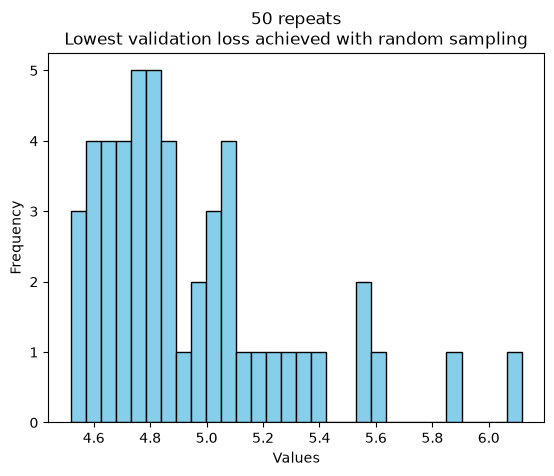

In [16]:
import matplotlib.pyplot as plt

print(len(lowest_losses))
print("Mean:", np.mean(lowest_losses))
print("Population stdev:", np.std(lowest_losses))
print("Sample stdev:", np.std(lowest_losses, ddof=1))

plt.hist(lowest_losses, bins=30, color='skyblue', edgecolor='black')

plt.title(f'50 repeats\nLowest validation loss achieved with random sampling')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()